In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approximate haploid genome length (Mb)
GENOME_LENGTH_MB = 2880

PLINK_FILE = "plink_ibd.genome"
GERMLINE_FILE = "germline_single_16bit.match"

In [2]:
def load_plink_results(filepath):

    if not os.path.exists(filepath):
        print("PLINK file not found")
        return pd.DataFrame()

    df = pd.read_csv(filepath, delim_whitespace=True)

    if "IID1" not in df.columns:
        df["IID1"] = df.iloc[:, 1].astype(str)
        df["IID2"] = df.iloc[:, 3].astype(str)
        df["PI_HAT"] = pd.to_numeric(df.iloc[:, 6], errors="coerce")

    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([r["IID1"], r["IID2"]])),
        axis=1
    )

    return df[["pair_id", "IID1", "IID2", "PI_HAT"]]

In [3]:
def load_germline_results(filepath):

    if not os.path.exists(filepath) or os.path.getsize(filepath) == 0:
        print("GERMLINE output empty")
        return pd.DataFrame()

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        header=None,
        engine="python"
    )

    print("GERMLINE detected columns:", df.shape[1])

    if df.shape[1] < 11:
        print("Unexpected GERMLINE format")
        return pd.DataFrame()

    df["IID1"] = df.iloc[:, 0].astype(str)
    df["IID2"] = df.iloc[:, 2].astype(str)
    start = pd.to_numeric(df.iloc[:, 5], errors="coerce")
    end = pd.to_numeric(df.iloc[:, 6], errors="coerce")
    chr_col = pd.to_numeric(df.iloc[:, 4], errors="coerce")

    length = pd.to_numeric(df.iloc[:, 10], errors="coerce")

    out = pd.DataFrame({
        "IID1": df["IID1"],
        "IID2": df["IID2"],
        "start": start,
        "end": end,
        "length": length,
        "chr": chr_col
    })

    before = len(out)
    out = out[out["start"] != out["end"]].reset_index(drop=True)
    after = len(out)
    print(f"Filtered {before - after} degenerate segments (start==end), {after} remain")

    print("out:\n")
    print(out)

    return out

In [4]:
def compute_germline_relatedness(df):

    if df.empty:
        return pd.DataFrame(columns=["pair_id", "GERMLINE_score"])

    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([str(r["IID1"]), str(r["IID2"])])),
        axis=1
    )

    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["start", "end"])

    grouped = df.groupby(["pair_id", "chr"])

    def merge_intervals(group):

        group = group.sort_values("start")

        merged_length = 0

        curr_start = group.iloc[0]["start"]
        curr_end = group.iloc[0]["end"]

        for _, row in group.iloc[1:].iterrows():

            if row["start"] <= curr_end:
                curr_end = max(curr_end, row["end"])
            else:
                merged_length += curr_end - curr_start
                curr_start = row["start"]
                curr_end = row["end"]

        merged_length += curr_end - curr_start

        # Convert bp → Mb
        return merged_length / 1e6

    # Apply merging
    merged_records = grouped.apply(
        merge_intervals
    ).reset_index(name="merged_mb")

    # Sum across chromosomes
    pair_lengths = merged_records.groupby("pair_id")[
        "merged_mb"
    ].sum().reset_index()

    # Normalize relatedness score
    GENOME_LENGTH_CM = 3600

    pair_lengths["GERMLINE_score"] = pair_lengths["merged_mb"] / GENOME_LENGTH_MB

    print("pair lengths normalized\n")
    print(pair_lengths)

    return pair_lengths[["pair_id", "GERMLINE_score"]]


# ===============================
# Merge Results
# ===============================

def merge_results(plink_df, germline_df):

    print("PLINK pairs example:")
    print(plink_df["pair_id"].head())

    print("\nGERMLINE pairs example:")
    print(germline_df["pair_id"].head())

    merged = pd.merge(
        plink_df,
        germline_df,
        on="pair_id",
        how="inner"
    )

    return merged

In [5]:
# ===============================
# Analysis
# ===============================

def analyze_results(merged_df):

    print("\n===== Summary Statistics =====")

    if merged_df.empty or len(merged_df) < 2:
        print("Not enough data points for correlation analysis.")
        print(f"Matched pairs = {len(merged_df)}")
        return

    print("\nPLINK PI_HAT:")
    print(merged_df["PI_HAT"].describe())

    print("\nGERMLINE Score:")
    print(merged_df["GERMLINE_score"].describe())

    try:
        corr, pval = pearsonr(
            merged_df["PI_HAT"],
            merged_df["GERMLINE_score"]
        )

        print("\n===== Correlation Analysis =====")
        print(f"Pearson correlation = {corr:.4f}")
        print(f"p-value = {pval:.4e}")

    except Exception:
        print("Correlation computation failed")

# ===============================
# Plotting
# ===============================

def plot_scatter(merged_df):

    plt.figure(figsize=(8,6))

    plt.scatter(
        merged_df["PI_HAT"],
        merged_df["GERMLINE_score"],
        alpha=0.6
    )

    # Identity reference line
    plt.plot([0,1],[0,1], linestyle="--")

    plt.xlabel("PLINK PI_HAT")
    plt.ylabel("GERMLINE Relatedness Score")
    plt.title("PLINK vs GERMLINE Relatedness Comparison")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Loading PLINK results...
Loading GERMLINE results...
GERMLINE detected columns: 15
Filtered 0 degenerate segments (start==end), 553 remain
out:

        IID1     IID2     start       end  length  chr
0    NA19331  NA19334    752566   3400294   5.449    1
1    NA19331  NA19334  17580568  18722846   3.141    1
2    NA19434  NA19444  22622513  43696080  25.330    1
3    NA19443  NA19470  13867459  48530258  46.863    1
4    NA19396  NA19397  18978482  75566564  63.837    1
..       ...      ...       ...       ...     ...  ...
548  NA19331  NA19334  16494187  37629938  44.258   22
549  NA19347  NA19352  36542194  44560839  11.396   22
550  NA19331  NA19334  37748394  47715107  16.587   22
551  NA19434  NA19444  38054262  48019799  16.418   22
552  NA19373  NA19374  46496023  51026207  14.010   22

[553 rows x 6 columns]


C:\Users\jpiepkorn\AppData\Local\Temp\ipykernel_7144\2068880601.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True)
C:\Users\jpiepkorn\AppData\Local\Temp\ipykernel_7144\1725233831.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_records = grouped.apply(


pair lengths normalized

             pair_id  merged_mb  GERMLINE_score
0    NA19020_NA19321  26.183227        0.009091
1    NA19020_NA19350  26.183227        0.009091
2    NA19020_NA19373   0.746321        0.000259
3    NA19020_NA19379  25.235514        0.008762
4    NA19020_NA19381  25.166831        0.008738
..               ...        ...             ...
341  NA19463_NA19473   2.551179        0.000886
342  NA19466_NA19468  25.003437        0.008682
343  NA19466_NA19471   0.290926        0.000101
344  NA19466_NA19473  25.003437        0.008682
345  NA19468_NA19473  25.003437        0.008682

[346 rows x 3 columns]
Merging datasets...
PLINK pairs example:
0    NA19020_NA19028
1    NA19020_NA19035
2    NA19020_NA19036
3    NA19020_NA19038
4    NA19020_NA19041
Name: pair_id, dtype: object

GERMLINE pairs example:
0    NA19020_NA19321
1    NA19020_NA19350
2    NA19020_NA19373
3    NA19020_NA19379
4    NA19020_NA19381
Name: pair_id, dtype: object

Matched pairs = 346

===== Summary Stati

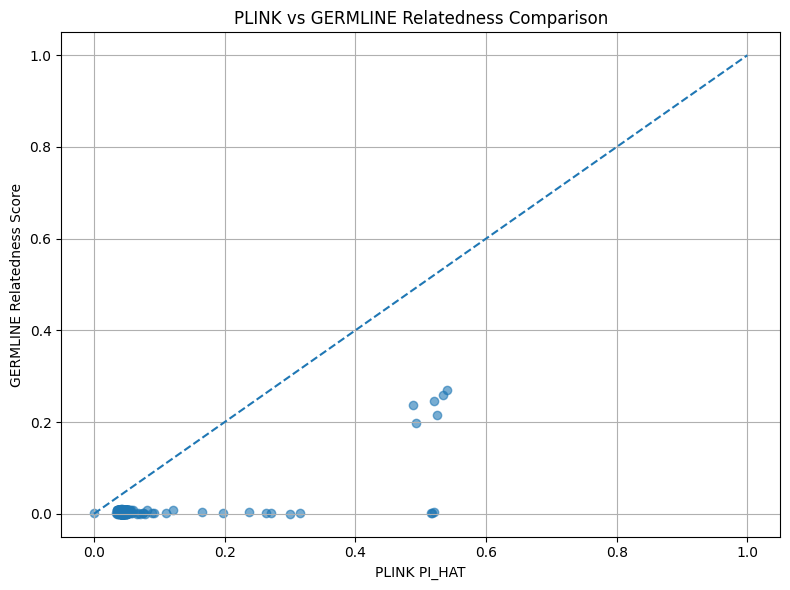

In [6]:
# ===============================
# Main
# ===============================

def main():

    print("Loading PLINK results...")
    plink_df = load_plink_results(PLINK_FILE)

    print("Loading GERMLINE results...")
    germline_raw = load_germline_results(GERMLINE_FILE)

    germline_df = compute_germline_relatedness(germline_raw)

    print("Merging datasets...")
    merged_df = merge_results(plink_df, germline_df)

    print(f"\nMatched pairs = {len(merged_df)}")

    analyze_results(merged_df)

    plot_scatter(merged_df)

    return plink_df, germline_df, merged_df


plink_df, germline_df, merged_df = main()

In [7]:
print("PLINK output columns:")
print(plink_df.columns)

print("\nSample PLINK rows:")
print(plink_df.head())

print("\nPI_HAT summary:")
print(plink_df["PI_HAT"].describe())

PLINK output columns:
Index(['pair_id', 'IID1', 'IID2', 'PI_HAT'], dtype='object')

Sample PLINK rows:
           pair_id     IID1     IID2  PI_HAT
0  NA19020_NA19028  NA19020  NA19028  0.0419
1  NA19020_NA19035  NA19020  NA19035  0.0400
2  NA19020_NA19036  NA19020  NA19036  0.0435
3  NA19020_NA19038  NA19020  NA19038  0.0401
4  NA19020_NA19041  NA19020  NA19041  0.0401

PI_HAT summary:
count    4656.000000
mean        0.045826
std         0.024539
min         0.000000
25%         0.041200
50%         0.043700
75%         0.046700
max         0.540700
Name: PI_HAT, dtype: float64


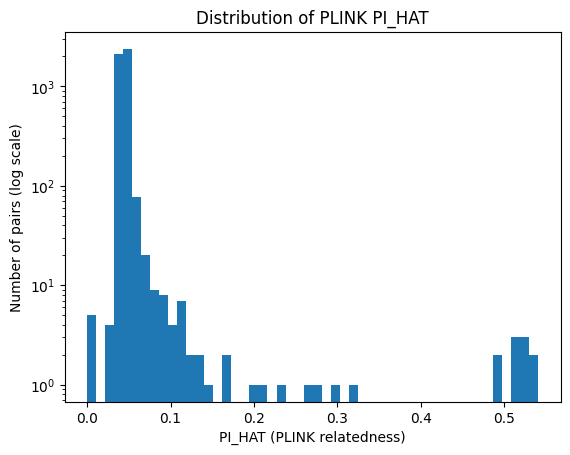

In [8]:
plt.figure()

plt.hist(plink_df["PI_HAT"], bins=50)

plt.yscale("log") # NOTE THAT WE USE LOG SCALE SO THAT WE CAN STILL SEE SMALLER Y VALUES SHOW UP ON THE GRAPH
plt.xlabel("PI_HAT (PLINK relatedness)")
plt.ylabel("Number of pairs (log scale)")
plt.title("Distribution of PLINK PI_HAT")

plt.show()

In [9]:
print("GERMLINE segment examples:")
print(germline_df.head())

print("\nTotal segments detected:")
print(len(germline_df))

GERMLINE segment examples:
           pair_id  GERMLINE_score
0  NA19020_NA19321        0.009091
1  NA19020_NA19350        0.009091
2  NA19020_NA19373        0.000259
3  NA19020_NA19379        0.008762
4  NA19020_NA19381        0.008738

Total segments detected:
346


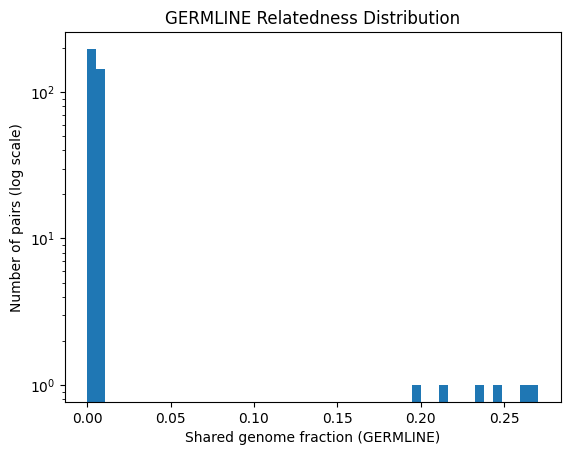

In [10]:
plt.figure()

plt.hist(germline_df["GERMLINE_score"], bins=50)

plt.yscale("log") # NOTE THAT WE USE LOG SCALE SO THAT WE CAN STILL SEE SMALLER Y VALUES SHOW UP ON THE GRAPH
plt.xlabel("Shared genome fraction (GERMLINE)")
plt.ylabel("Number of pairs (log scale)")
plt.title("GERMLINE Relatedness Distribution")

plt.show()

In [11]:
plink_related = (merged_df["PI_HAT"] > 0.1).sum()
germline_related = (merged_df["GERMLINE_score"] > 0).sum()

print("Pairs detected by PLINK:", plink_related)
print("Pairs detected by GERMLINE:", germline_related)

Pairs detected by PLINK: 18
Pairs detected by GERMLINE: 346


We see a discrepancy in the number of pairs detected by PLINK and GERMLINE due to how they fundamentally calculate relative finding. PLINK compares allele frequencies across SNPs and estimates how many alleles two people share. From this, it computes PI_HAT, which is an appromixation for the proportion of the genome shared IBD. Because this approach relies on statistics and approximation, it is very possible to detect weaker signals of relatedness and will likely find more pairs. In contrast, GERMLINE searches for continuous slices of DNA that match. From our data generation, we required 3 cM of DNA to be identical in order to count it as a match. Therefore, distant relatives and random chance findings are less likely to be included in the final pairs detected.

In [12]:
def relationship_category(pi):
    if pi > 0.45:
        return "1st degree"
    elif pi > 0.2:
        return "2nd degree"
    elif pi > 0.1:
        return "3rd degree"
    else:
        return "unrelated"

merged_df["relationship"] = merged_df["PI_HAT"].apply(relationship_category)

print(merged_df["relationship"].value_counts())

relationship
unrelated     328
1st degree      9
2nd degree      5
3rd degree      4
Name: count, dtype: int64


A vast majority of the dataset are not closely related, which is to be expected. First-degree relatives share approximately 50% of their genome. Some examples include parent-child relationships and full sibling relationships. PI_HAT must be roughly 0.5 and the shared distance roughly 1400 Mb. We see that our python notebook detected 10 pairs that meet these metrics. Second-degree relatives share close to 25% of their genome, like grandchild-grandparents and half siblings. Third-degree relatives share about 12.5%  of their genome. Due to the fact that these relationships consist of shorter IBD segments, PLINK can detect them but GERMLINE can potentially miss finding some if their segments are too short.

## Runtime & Memory Usage: PLINK vs GERMLINE

Run the benchmark first from WSL:
```bash
conda activate bio_bench
bash benchmark.sh
```
This produces `benchmark_results.csv` with wall-clock time and peak RSS for each tool.

In [13]:
# ===============================
# Load Benchmark Results (3 runs → mean)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BENCHMARK_FILE = "benchmark_results.csv"

raw = pd.read_csv(BENCHMARK_FILE)

# Handle missing 'run' column (older CSV format)
if "run" not in raw.columns:
    raw["run"] = raw.groupby("tool").cumcount() + 1

raw["max_rss_mb"] = raw["max_rss_kb"] / 1024.0   # KB → MB

print("=== All Runs ===")
print(raw.to_string(index=False))

# Compute mean across runs for each tool
bench = raw.groupby("tool").agg(
    wall_seconds=("wall_seconds", "mean"),
    user_seconds=("user_seconds", "mean"),
    sys_seconds=("sys_seconds", "mean"),
    max_rss_kb=("max_rss_kb", "mean"),
    max_rss_mb=("max_rss_mb", "mean"),
    wall_std=("wall_seconds", "std"),
    rss_std=("max_rss_mb", "std"),
    n_runs=("run", "count"),
).reset_index()

print("\n=== Mean of 3 Runs ===")
print(bench.to_string(index=False))

=== All Runs ===
    tool  run  wall_seconds  user_seconds  sys_seconds  max_rss_kb  max_rss_mb
   PLINK    1         30.34          1.46         2.37       43648   42.625000
   PLINK    2         25.82          1.22         2.38       43448   42.429688
   PLINK    3         29.61          1.54         2.72       43816   42.789062
GERMLINE    1        102.53          3.77         2.62       92816   90.640625
GERMLINE    2         84.04          3.70         2.44       92872   90.695312
GERMLINE    3         73.46          3.34         2.34       92692   90.519531

=== Mean of 3 Runs ===
    tool  wall_seconds  user_seconds  sys_seconds   max_rss_kb  max_rss_mb  wall_std  rss_std  n_runs
GERMLINE     86.676667      3.603333     2.466667 92793.333333   90.618490 14.713267 0.089957       3
   PLINK     28.590000      1.406667     2.490000 43637.333333   42.614583  2.426500 0.179914       3


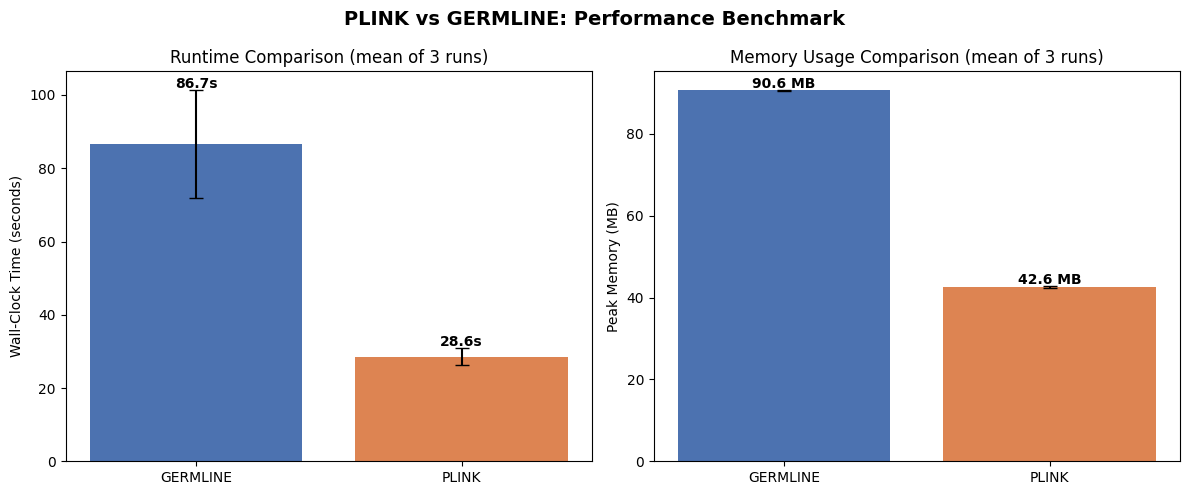


===== Performance Summary (mean of 3 runs) =====
GERMLINE    Wall: 86.7s (±14.7)  |  User: 3.6s  |  Sys: 2.5s  |  Peak RSS: 90.6 MB (±0.1)
PLINK       Wall: 28.6s (±2.4)  |  User: 1.4s  |  Sys: 2.5s  |  Peak RSS: 42.6 MB (±0.2)

PLINK is 3.0x faster
PLINK uses 2.1x less memory


In [14]:
# ===============================
# Runtime Comparison (Bar Chart with error bars)
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#4C72B0", "#DD8452"]

# --- Wall-clock time (mean ± std) ---
axes[0].bar(bench["tool"], bench["wall_seconds"],
            yerr=bench["wall_std"].fillna(0), capsize=5, color=colors)
axes[0].set_ylabel("Wall-Clock Time (seconds)")
axes[0].set_title("Runtime Comparison (mean of 3 runs)")
for i, (v, s) in enumerate(zip(bench["wall_seconds"], bench["wall_std"].fillna(0))):
    axes[0].text(i, v + s + 0.5, f"{v:.1f}s", ha="center", fontweight="bold")

# --- Peak memory ---
rss_std_clean = bench["rss_std"].fillna(0)
axes[1].bar(bench["tool"], bench["max_rss_mb"],
            yerr=rss_std_clean, capsize=5, color=colors)
axes[1].set_ylabel("Peak Memory (MB)")
axes[1].set_title("Memory Usage Comparison (mean of 3 runs)")
for i, (v, s) in enumerate(zip(bench["max_rss_mb"], rss_std_clean)):
    axes[1].text(i, v + s + 0.5, f"{v:.1f} MB", ha="center", fontweight="bold")

plt.suptitle("PLINK vs GERMLINE: Performance Benchmark", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary ---
print("\n===== Performance Summary (mean of 3 runs) =====")
for _, row in bench.iterrows():
    std_wall = row['wall_std'] if not np.isnan(row['wall_std']) else 0
    std_rss = row['rss_std'] if not np.isnan(row['rss_std']) else 0
    print(f"{row['tool']:10s}  Wall: {row['wall_seconds']:.1f}s (±{std_wall:.1f})  |  "
          f"User: {row['user_seconds']:.1f}s  |  "
          f"Sys: {row['sys_seconds']:.1f}s  |  "
          f"Peak RSS: {row['max_rss_mb']:.1f} MB (±{std_rss:.1f})")

if len(bench) == 2:
    wall0 = bench.iloc[0]["wall_seconds"]
    wall1 = bench.iloc[1]["wall_seconds"]
    rss0 = bench.iloc[0]["max_rss_mb"]
    rss1 = bench.iloc[1]["max_rss_mb"]

    if wall0 > 0 and wall1 > 0:
        speedup = wall1 / wall0
        faster = bench.iloc[0]["tool"] if speedup > 1 else bench.iloc[1]["tool"]
        print(f"\n{faster} is {max(speedup, 1/speedup):.1f}x faster")

    if rss0 > 0 and rss1 > 0 and not (np.isnan(rss0) or np.isnan(rss1)):
        mem_ratio = rss1 / rss0
        leaner = bench.iloc[0]["tool"] if mem_ratio > 1 else bench.iloc[1]["tool"]
        print(f"{leaner} uses {max(mem_ratio, 1/mem_ratio):.1f}x less memory")
    else:
        print("Memory comparison unavailable (missing data)")